In [1]:
# Import library utama
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Cetak versi TensorFlow
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
# Memuat dataset Fashion-MNIST
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalisasi data gambar ke rentang 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Definisikan nama kelas untuk referensi nanti
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Menampilkan dimensi data
print("Bentuk data latih (gambar):", x_train.shape)
print("Bentuk data latih (label):", y_train.shape)
print("Bentuk data uji (gambar):", x_test.shape)
print("Bentuk data uji (label):", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Bentuk data latih (gambar): (60000, 28, 28)
Bentuk data latih (label): (60000,)
Bentuk data uji (gambar): (10000, 28, 28)
Bentuk data uji (label): (10000,)


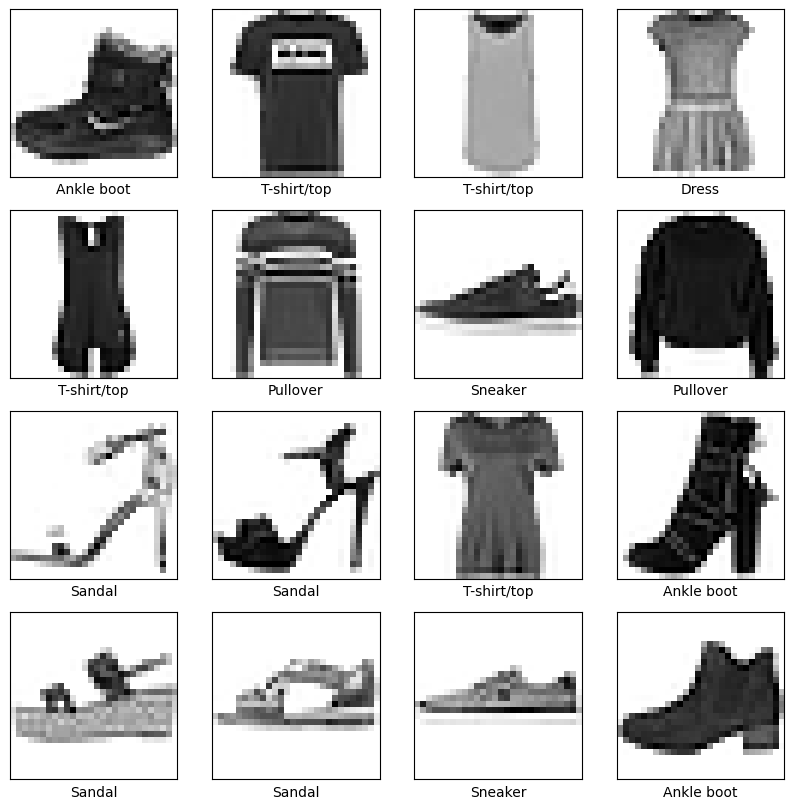

In [3]:
# Menampilkan 16 gambar pertama dari dataset
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [4]:
# Membangun model MLP
model_mlp = keras.Sequential([
    # Meratakan gambar 28x28 menjadi vektor 1D (784 elemen)
    layers.Flatten(input_shape=(28, 28)),

    # Lapisan tersembunyi (hidden layer) dengan 128 neuron
    layers.Dense(128, activation='relu'),

    # Lapisan output dengan 10 neuron (sesuai jumlah kelas)
    # Aktivasi softmax untuk klasifikasi multikelas
    layers.Dense(10, activation='softmax')
])

# Kompilasi model
model_mlp.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Menampilkan arsitektur model MLP
model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("Memulai pelatihan model JST Konvensional (MLP)...")
history_mlp = model_mlp.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,  # Menggunakan 20% data latih untuk validasi
    verbose=2
)
print("Pelatihan model MLP selesai.")

Memulai pelatihan model JST Konvensional (MLP)...
Epoch 1/10
1500/1500 - 6s - 4ms/step - accuracy: 0.8189 - loss: 0.5175 - val_accuracy: 0.8464 - val_loss: 0.4204
Epoch 2/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8603 - loss: 0.3874 - val_accuracy: 0.8526 - val_loss: 0.4057
Epoch 3/10
1500/1500 - 4s - 2ms/step - accuracy: 0.8739 - loss: 0.3479 - val_accuracy: 0.8705 - val_loss: 0.3526
Epoch 4/10
1500/1500 - 4s - 2ms/step - accuracy: 0.8826 - loss: 0.3211 - val_accuracy: 0.8684 - val_loss: 0.3670
Epoch 5/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8910 - loss: 0.3002 - val_accuracy: 0.8815 - val_loss: 0.3283
Epoch 6/10
1500/1500 - 4s - 3ms/step - accuracy: 0.8944 - loss: 0.2868 - val_accuracy: 0.8826 - val_loss: 0.3256
Epoch 7/10
1500/1500 - 4s - 2ms/step - accuracy: 0.9020 - loss: 0.2690 - val_accuracy: 0.8827 - val_loss: 0.3343
Epoch 8/10
1500/1500 - 4s - 3ms/step - accuracy: 0.9038 - loss: 0.2602 - val_accuracy: 0.8746 - val_loss: 0.3505
Epoch 9/10
1500/1500 - 4s - 3ms/step - accurac

In [6]:
# Menyesuaikan bentuk data untuk input CNN (menambah channel warna)
x_train_cnn = np.expand_dims(x_train, -1)
x_test_cnn = np.expand_dims(x_test, -1)

print("Bentuk data baru untuk CNN:", x_train_cnn.shape)

# Membangun model CNN
model_cnn = keras.Sequential([
    # Lapisan konvolusi pertama
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Lapisan konvolusi kedua
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Meratakan hasil ekstraksi fitur sebelum masuk ke lapisan Dense
    layers.Flatten(),

    # Lapisan Dense untuk klasifikasi
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Kompilasi model
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Menampilkan arsitektur model CNN
model_cnn.summary()

Bentuk data baru untuk CNN: (60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("\nMemulai pelatihan model Deep Learning (CNN)...")
history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)
print("Pelatihan model CNN selesai.")


Memulai pelatihan model Deep Learning (CNN)...
Epoch 1/10
1500/1500 - 6s - 4ms/step - accuracy: 0.8253 - loss: 0.4772 - val_accuracy: 0.8717 - val_loss: 0.3598
Epoch 2/10
1500/1500 - 5s - 3ms/step - accuracy: 0.8840 - loss: 0.3176 - val_accuracy: 0.8844 - val_loss: 0.3157
Epoch 3/10
1500/1500 - 5s - 4ms/step - accuracy: 0.9037 - loss: 0.2655 - val_accuracy: 0.8983 - val_loss: 0.2768
Epoch 4/10
1500/1500 - 5s - 3ms/step - accuracy: 0.9130 - loss: 0.2335 - val_accuracy: 0.9024 - val_loss: 0.2639
Epoch 5/10
1500/1500 - 5s - 4ms/step - accuracy: 0.9235 - loss: 0.2066 - val_accuracy: 0.9059 - val_loss: 0.2562
Epoch 6/10
1500/1500 - 5s - 3ms/step - accuracy: 0.9312 - loss: 0.1829 - val_accuracy: 0.9080 - val_loss: 0.2547
Epoch 7/10
1500/1500 - 5s - 3ms/step - accuracy: 0.9398 - loss: 0.1622 - val_accuracy: 0.9107 - val_loss: 0.2544
Epoch 8/10
1500/1500 - 5s - 4ms/step - accuracy: 0.9465 - loss: 0.1405 - val_accuracy: 0.9120 - val_loss: 0.2544
Epoch 9/10
1500/1500 - 5s - 3ms/step - accuracy:

In [9]:
# Evaluasi model MLP
loss_mlp, acc_mlp = model_mlp.evaluate(x_test, y_test, verbose=0)

# Evaluasi model CNN
loss_cnn, acc_cnn = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)

print("--- Hasil Perbandingan Kinerja pada Data Uji ---")
print(f"Akurasi JST Konvensional (MLP): {acc_mlp*100:.2f}%")
print(f"Akurasi Deep Learning (CNN):    {acc_cnn*100:.2f}%")
print("\n")
print(f"Loss JST Konvensional (MLP): {loss_mlp:.4f}")
print(f"Loss Deep Learning (CNN):    {loss_cnn:.4f}")

--- Hasil Perbandingan Kinerja pada Data Uji ---
Akurasi JST Konvensional (MLP): 87.96%
Akurasi Deep Learning (CNN):    89.52%


Loss JST Konvensional (MLP): 0.3419
Loss Deep Learning (CNN):    0.3336


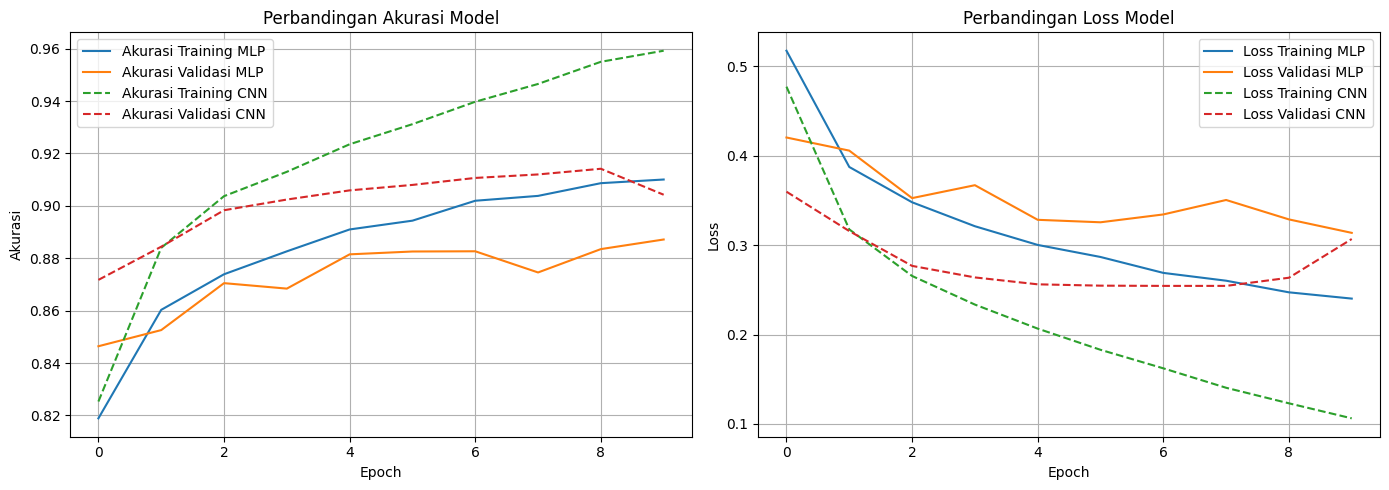

In [10]:
plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='Akurasi Training MLP')
plt.plot(history_mlp.history['val_accuracy'], label='Akurasi Validasi MLP')
plt.plot(history_cnn.history['accuracy'], label='Akurasi Training CNN', linestyle='--')
plt.plot(history_cnn.history['val_accuracy'], label='Akurasi Validasi CNN', linestyle='--')
plt.title('Perbandingan Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='Loss Training MLP')
plt.plot(history_mlp.history['val_loss'], label='Loss Validasi MLP')
plt.plot(history_cnn.history['loss'], label='Loss Training CNN', linestyle='--')
plt.plot(history_cnn.history['val_loss'], label='Loss Validasi CNN', linestyle='--')
plt.title('Perbandingan Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step


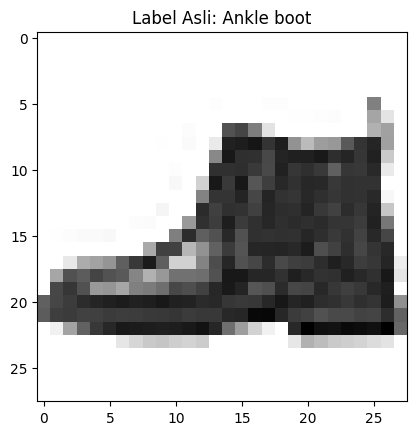

Prediksi JST Konvensional (MLP): Ankle boot
Prediksi Deep Learning (CNN):    Ankle boot


In [11]:
# Ambil satu gambar acak dari data uji
idx = np.random.randint(0, x_test.shape[0])
sample_image = x_test[idx]
sample_label = y_test[idx]

# Prediksi menggunakan MLP
pred_mlp_prob = model_mlp.predict(np.array([sample_image]))
pred_mlp_class = np.argmax(pred_mlp_prob)

# Prediksi menggunakan CNN
# Ingat, CNN butuh input 4D (batch_size, height, width, channels)
sample_image_cnn = np.expand_dims(sample_image, axis=(0, -1))
pred_cnn_prob = model_cnn.predict(sample_image_cnn)
pred_cnn_class = np.argmax(pred_cnn_prob)

# Tampilkan hasilnya
plt.imshow(sample_image, cmap=plt.cm.binary)
plt.title(f"Label Asli: {class_names[sample_label]}")
plt.show()

print(f"Prediksi JST Konvensional (MLP): {class_names[pred_mlp_class]}")
print(f"Prediksi Deep Learning (CNN):    {class_names[pred_cnn_class]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


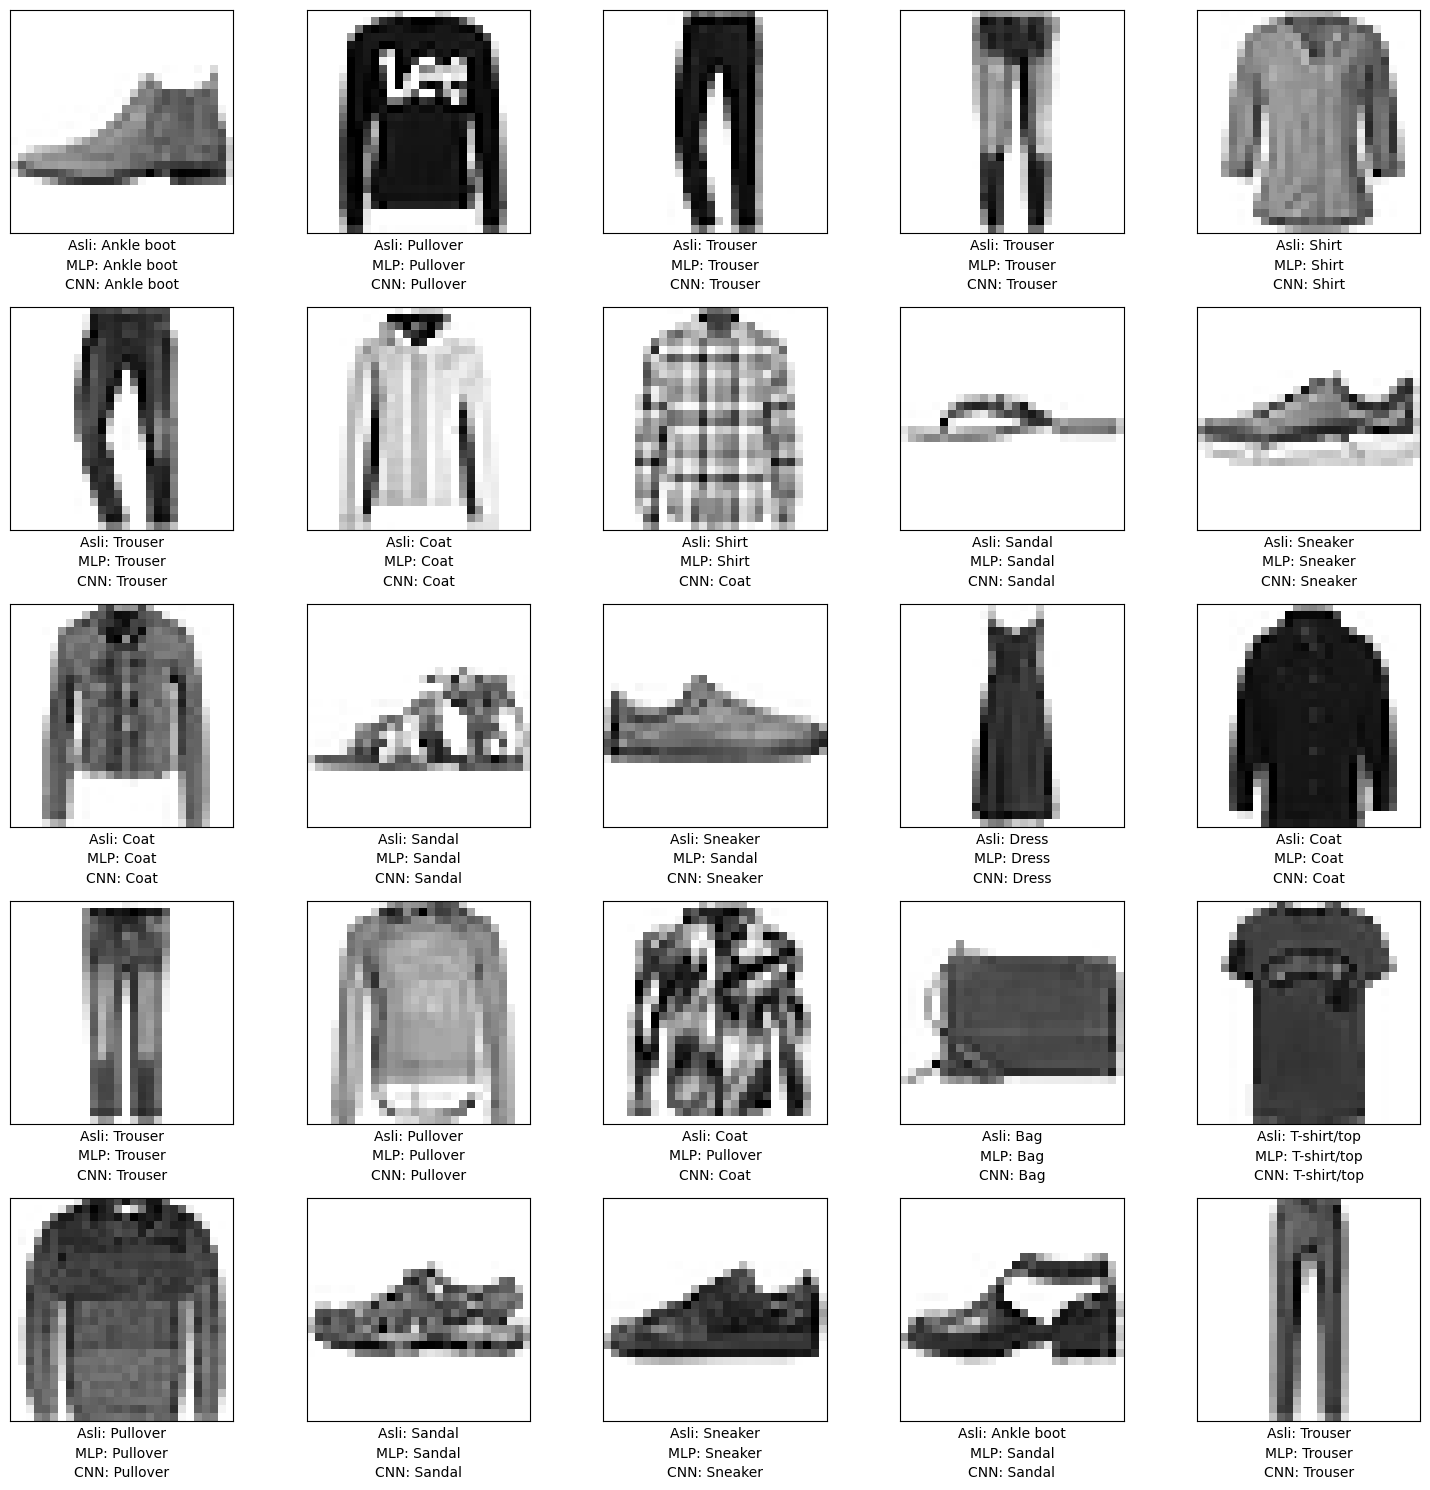

In [12]:
# Fungsi untuk memplot gambar, label asli, dan label prediksi
def plot_image_predictions(images, labels, pred_mlp, pred_cnn, class_names):
    plt.figure(figsize=(15, 15))
    for i in range(min(25, len(images))):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)

        true_label = class_names[labels[i]]
        mlp_label = class_names[pred_mlp[i]]
        cnn_label = class_names[pred_cnn[i]]

        # Beri warna hijau jika benar, merah jika salah
        color_mlp = 'green' if true_label == mlp_label else 'red'
        color_cnn = 'green' if true_label == cnn_label else 'red'

        plt.xlabel(f"Asli: {true_label}\nMLP: {mlp_label}\nCNN: {cnn_label}",
                     color='black', linespacing=1.5)

        # Mengubah warna teks prediksi secara individual (membutuhkan sedikit trik)
        # Trik ini tidak langsung didukung, jadi kita tandai dengan warna pada label xlabel saja.
        # Jika ingin lebih canggih, perlu menggunakan plt.text secara terpisah.
        # Namun, cara di atas sudah cukup informatif.

    plt.tight_layout()
    plt.show()

# Dapatkan prediksi untuk seluruh data uji
# MLP
predictions_mlp_prob = model_mlp.predict(x_test)
predictions_mlp = np.argmax(predictions_mlp_prob, axis=1)

# CNN
predictions_cnn_prob = model_cnn.predict(x_test_cnn)
predictions_cnn = np.argmax(predictions_cnn_prob, axis=1)

# Panggil fungsi untuk menampilkan hasil
plot_image_predictions(x_test, y_test, predictions_mlp, predictions_cnn, class_names)

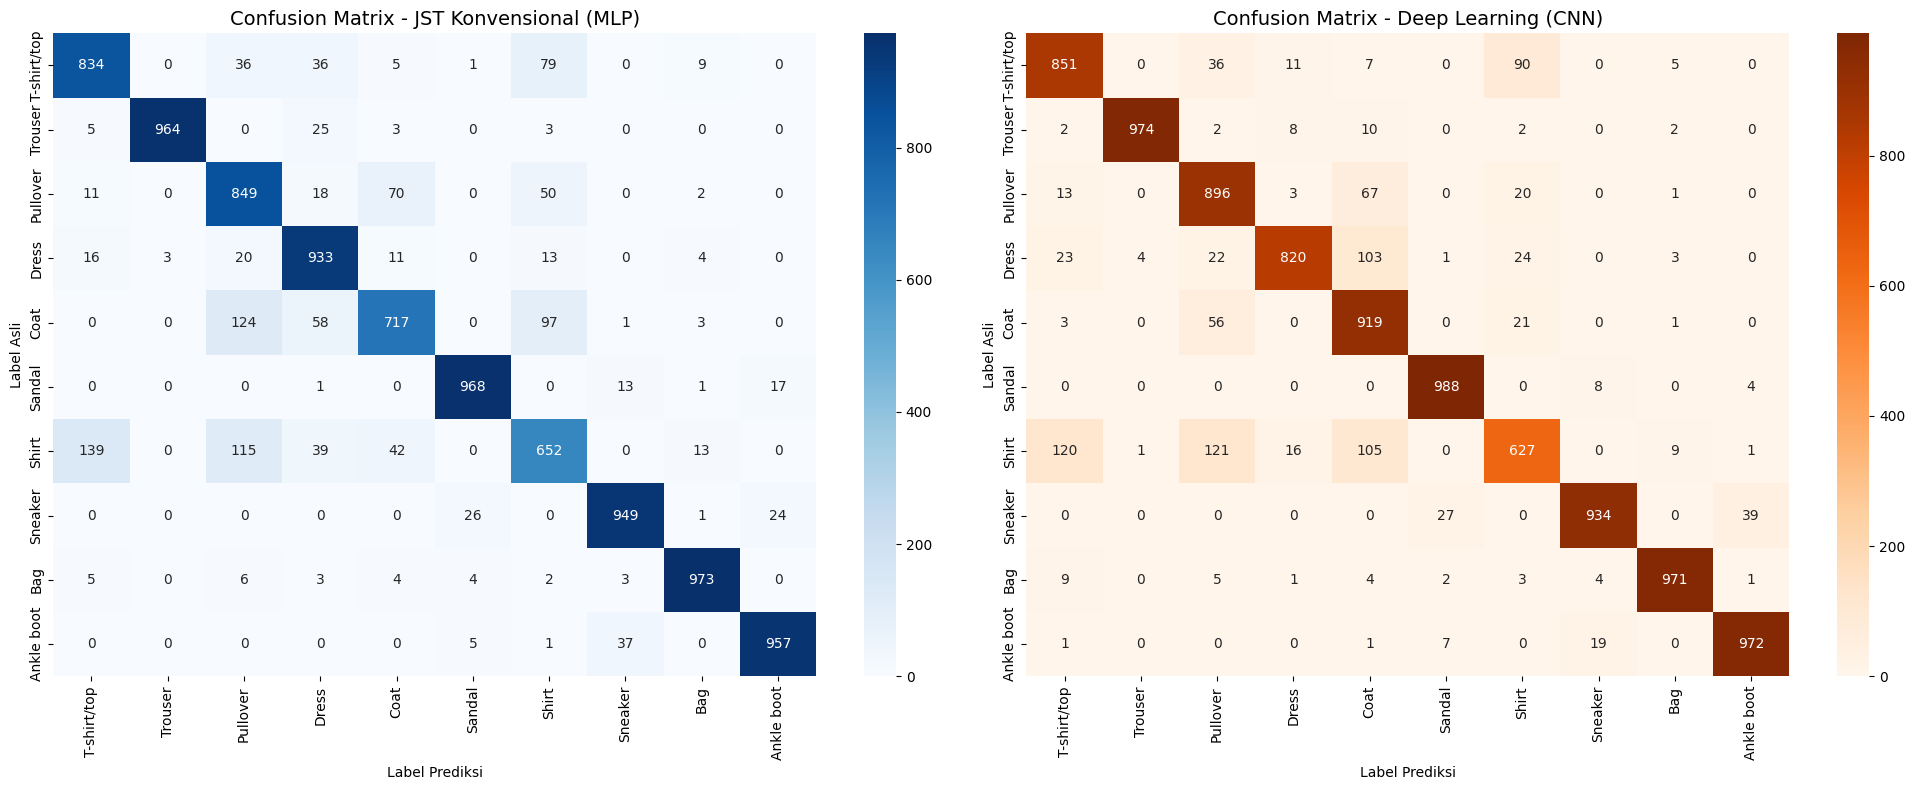

In [14]:
# Pastikan Anda sudah mengimpor ini di sel pertama:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Hitung confusion matrix untuk kedua model
cm_mlp = confusion_matrix(y_test, predictions_mlp)
cm_cnn = confusion_matrix(y_test, predictions_cnn)

# 2. Visualisasikan confusion matrix menggunakan heatmap
plt.figure(figsize=(20, 8))

# Confusion Matrix untuk MLP
plt.subplot(1, 2, 1)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - JST Konvensional (MLP)', fontsize=14)
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')

# Confusion Matrix untuk CNN
plt.subplot(1, 2, 2)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Deep Learning (CNN)', fontsize=14)
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')

plt.tight_layout()
plt.show()

In [16]:
# Pastikan Anda sudah mengimpor ini di sel pertama:
from sklearn.metrics import classification_report

# Membuat laporan klasifikasi untuk JST Konvensional (MLP)
print("--- Laporan Klasifikasi: JST Konvensional (MLP) ---")
report_mlp = classification_report(y_test, predictions_mlp, target_names=class_names)
print(report_mlp)

# Membuat laporan klasifikasi untuk Deep Learning (CNN)
print("\n--- Laporan Klasifikasi: Deep Learning (CNN) ---")
report_cnn = classification_report(y_test, predictions_cnn, target_names=class_names)
print(report_cnn)

--- Laporan Klasifikasi: JST Konvensional (MLP) ---
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.83      0.83      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.74      0.85      0.79      1000
       Dress       0.84      0.93      0.88      1000
        Coat       0.84      0.72      0.77      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.73      0.65      0.69      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


--- Laporan Klasifikasi: Deep Learning (CNN) ---
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0